In [1]:
import numpy as np
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.neighbors import KernelDensity

class BayesKDE(BaseEstimator, ClassifierMixin):
  def __init__(self, bandwidth=1.0):
    self.bandwidth = bandwidth

  def fit(self, X, y):
    self.classes_ = np.unique(y)

    self.kdes_ = {}
    self.priors_ = {}

    for target in self.classes_:
      kde = KernelDensity(kernel='gaussian', bandwidth=self.bandwidth)
      kde.fit(X[y == target])
      self.kdes_[target] = kde

      self.priors_[target] = np.sum(y == target) / len(y)

    return self
  
  def score_samples(self, X):
    logprobs = np.zeros((len(X), len(self.classes_)))

    for i, target in enumerate(self.classes_):
      logprobs[:, i] = self.kdes_[target].score_samples(X) + np.log(self.priors_[target])

    return logprobs
  
  def predict(self, X):
    logprobs = self.score_samples(X)
    return np.argmax(logprobs, axis=1)

In [2]:
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold

def load_pima_diabetes():
  url = (
    "https://raw.githubusercontent.com/jbrownlee/Datasets/"
    "master/pima-indians-diabetes.data.csv"
  )
  cols = [
    "Pregnancies", "Glucose", "BloodPressure", "SkinThickness",
    "Insulin", "BMI", "DiabetesPedigreeFunction", "Age", "Outcome"
  ]
  df = pd.read_csv(url, header=None, names=cols)
  
  features = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
  
  for feat in features:
    df[feat] = df[feat].replace(0, np.nan)
    df[feat] = df[feat].fillna(df[feat].median())
  
  X = df.drop("Outcome", axis=1).values
  y = df["Outcome"].values
  return X, y

def preprocess_data(X, y):
  
  # Standardize the features
  scaler = StandardScaler()
  X_scaled = scaler.fit_transform(X)
  
  # Convert to DataFrame for easier manipulation
  X_df = pd.DataFrame(X_scaled)
  
  # Remove low variance features
  selector = VarianceThreshold(threshold=0.01)
  X_low_var_removed = selector.fit_transform(X_df)
  
  # Remove highly correlated features
  X_corr = pd.DataFrame(X_low_var_removed).corr().abs()
  upper_triangle = X_corr.where(
    np.triu(np.ones(X_corr.shape), k=1).astype(bool)
  )
  to_drop = [column for column in upper_triangle.columns if any(upper_triangle[column] > 0.9)]
  X_final = pd.DataFrame(X_low_var_removed).drop(columns=to_drop, axis=1)
  
  return X_final.values, y

X, y = load_pima_diabetes()
X, y = preprocess_data(X, y)

In [ ]:
import imageio
import os
import matplotlib.pyplot as plt

def compute_likelihood(bayeskde, X, y):
  bayeskde.fit(X, y)

  logprobs = bayeskde.score_samples(X)
  [Q0, Q1] = logprobs.T

  Q0, Q1 = np.exp(Q0), np.exp(Q1)

  return Q0, Q1

def plot_likelihood(Q0, Q1, y, title="likelihood"):
  plt.scatter(Q0, Q1, c=y)
  
  plt.xlabel('Q0')
  plt.ylabel('Q1')
  plt.grid()
  plt.title(title)
  plt.show()

def make_likelihood_gif(Qs, y, filename='likelihood_animation.gif'):
  filenames = []
  for idx, (h, Q0, Q1) in enumerate(Qs):
    plt.figure()
    plt.scatter(Q0, Q1, c=y)
    plt.xlabel('Q0')
    plt.ylabel('Q1')
    plt.title(f'Bandwidth: {h:.2f}')
    plt.grid(alpha=0.3)
    
    # Save frame
    frame_filename = f'frame_{idx:03d}.png'
    plt.savefig(frame_filename, dpi=100, bbox_inches='tight')
    plt.close()
    filenames.append(frame_filename)
  
  # Create GIF
  with imageio.get_writer(filename, mode='I', duration=0.3) as writer:
    for filename in filenames:
      image = imageio.v3.imread(filename)
      writer.append_data(image)
  
  # Cleanup temporary files
  for filename in filenames:
    os.remove(filename)


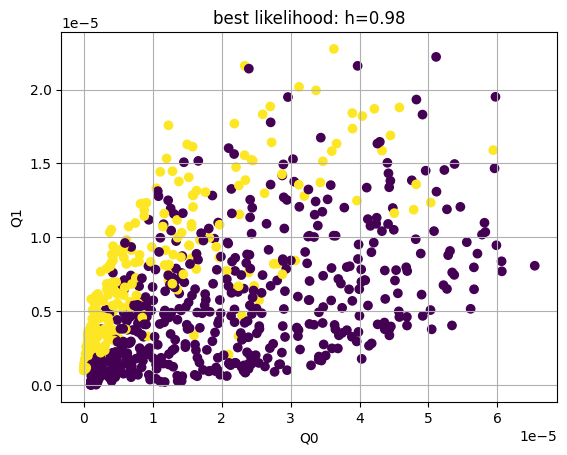

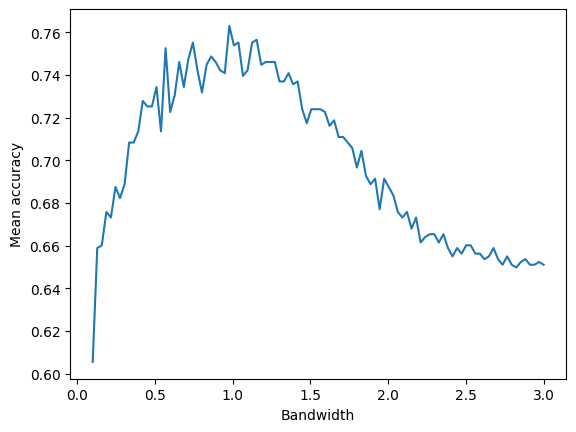

In [12]:
from sklearn.model_selection import cross_val_score, KFold

hs = np.linspace(0.1, 3, 100)

kf = KFold(n_splits=3, shuffle=True)
mean_scores = []
Qs = []

for h in hs:
  bayeskde = BayesKDE(bandwidth=h)
  scores = cross_val_score(bayeskde, X, y, cv=kf, scoring='accuracy')
  mean_scores.append(np.mean(scores))

  Q0, Q1 = compute_likelihood(bayeskde, X, y)
  Qs.append((h, Q0, Q1))

best_h = hs[np.argmax(mean_scores)]
best_bayeskde = BayesKDE(bandwidth=best_h)
best_Q0, best_Q1 = compute_likelihood(best_bayeskde, X, y)
plot_likelihood(best_Q0, best_Q1, y, title=f"best likelihood: h={best_h:.2f}")

make_likelihood_gif(Qs, y)

plt.figure()
plt.plot(hs, mean_scores)
plt.xlabel('Bandwidth')
plt.ylabel('Mean accuracy')
plt.savefig('bandwidth_vs_accuracy.png')
plt.show()

